# Jobs — Fit Label Classification (M3)

**Goal:** classify each (candidate, job) pairing as **Good / Average / Poor Fit** from the job's requirements and the applicant's match.

> The trivial `role`-from-`required_skills` task was **dropped**: skills are templated 1:1 to roles (10 fixed templates shared across train & test), so it scored a *fake* 100% — that's label leakage, not learning. This is the genuine task instead.

**Always-true design:** target = consistent label banded from the match `score` (good ≥ 63, average ≥ 45, else poor). Trained **leakage-free** — no `score` or sub-scores as features — yet a high match can never be called poor fit.

**Includes (M3):** y_pred, accuracy / macro-F1 / per-class report, confusion matrix, consistency check, feature importance, SHAP (bar + beeswarm), error analysis.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
%matplotlib inline
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# M3 shared modules (Section 7.1 metrics + Section 6.1 baseline)
_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)
from src.eval.metrics import regression_metrics, classification_metrics
from src.models.baseline import baseline_score, baseline_label

## 1. Load data

In [2]:
# Resolve the data path whether the notebook runs from repo root or notebooks/
DATA = "data/processed"
if not os.path.exists(os.path.join(DATA, "train.csv")):
    DATA = os.path.join("..", "data", "processed")

train_df = pd.read_csv(os.path.join(DATA, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA, "test.csv"))
print("train:", train_df.shape, "| test:", test_df.shape)
train_df.head(3)

train: (79840, 22) | test: (19960, 22)


,application_id,candidate_id,job_id,application_date,status,name,email,skills,experience_years,education,...,required_skills,min_experience,score,skills_match,experience_score,project_score,label,num_candidate_skills,num_required_skills,experience_difference
0,66735,30433,7,2026-03-11,applied,pooja li,pooja.li5775@zoho.com,django|flask|mysql|python|rabbitmq|redis,8,b.sc computer science,...,react|node.js|mongodb|express|postgresql|docke...,2,63.6,0.0,30.0,28.8,average fit,6,7,6
1,64779,29450,10,2025-08-03,interviewed,meera pillai,meera.pillai834@mail.com,jira|pytorch|spark|tensorflow,3,m.s. data science,...,agile|roadmapping|sql|jira|stakeholder managem...,4,56.0,4.1,22.5,29.7,average fit,4,6,-1
2,17695,5854,8,2025-09-27,shortlisted,ayesha kobayashi,ayesha.kobayashi53937@gmail.com,css|graphql|react|tailwind|typescript|vue.js|w...,6,m.tech information security,...,spark|kafka|airflow|python|sql|aws|hadoop|dbt,3,57.5,0.0,30.0,24.0,average fit,7,8,3


## 2. Clean — drop identifiers

In [3]:
for col in ["application_id", "candidate_id", "job_id", "name", "email"]:
    train_df.drop(columns=col, errors="ignore", inplace=True)
    test_df.drop(columns=col, errors="ignore", inplace=True)
print("identifiers dropped")

identifiers dropped


## 3. Feature engineering (leakage-free)

In [4]:
def engineer(df):
    """Leakage-free feature engineering (Section 5 of the spec)."""
    d = df.copy()
    cand = d["skills"].fillna("").str.split("|")
    req  = d["required_skills"].fillna("").str.split("|")
    d["skill_overlap_count"] = [len(set(a) & set(b)) for a, b in zip(cand, req)]
    d["skill_overlap_pct"]   = (d["skill_overlap_count"] /
                                 d["num_required_skills"].replace(0, np.nan)).fillna(0)
    d["experience_gap"]      = d["experience_years"] - d["min_experience"]
    d["experience_meets"]    = (d["experience_years"] >= d["min_experience"]).astype(int)
    d["project_count"]       = d["projects"].fillna("").str.split("|").apply(
                                   lambda x: len([p for p in x if p.strip()]))
    edu = d["education"].fillna("").str.lower()
    d["education_level"]     = np.select(
        [edu.str.contains("phd"),
         edu.str.contains("m.s|master|mba|m.tech"),
         edu.str.contains("b.s|bachelor|b.tech|b.e")], [3, 2, 1], default=0)
    return d

train_fe = engineer(train_df)
test_fe  = engineer(test_df)
train_fe[["skill_overlap_count","skill_overlap_pct","experience_gap",
          "experience_meets","project_count","education_level"]].head()

,skill_overlap_count,skill_overlap_pct,experience_gap,experience_meets,project_count,education_level
0,0,0.000000,6,1,3,1
1,1,0.166667,-1,0,3,2
2,0,0.000000,3,1,1,2
3,3,0.428571,12,1,1,2
4,1,0.142857,8,1,2,2


## 4. Consistent target + training

`label = band(score)` is the consistent ground truth; the model never sees `score`/sub-scores, so there is no leakage.

In [5]:
from sklearn.ensemble import RandomForestClassifier

def band(score):
    s = np.asarray(score, dtype=float)
    return np.where(s >= 63, "good fit", np.where(s >= 45, "average fit", "poor fit"))

# job-requirement + match features (no score, no sub-scores)
SAFE = ["min_experience", "num_required_skills", "num_candidate_skills",
        "experience_years", "experience_gap", "experience_meets",
        "skill_overlap_count", "skill_overlap_pct", "project_count",
        "education_level"]

X_train, y_train = train_fe[SAFE], band(train_df["score"])
X_test,  y_test  = test_fe[SAFE],  band(test_df["score"])

clf = RandomForestClassifier(n_estimators=150, max_depth=10,
                             random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred[:8]

array(['good fit', 'average fit', 'average fit', 'average fit',
       'average fit', 'poor fit', 'average fit', 'average fit'],
      dtype='<U11')

## 5. Classification metrics & baseline lift (spec 7.1 / 6.1)

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
m = classification_metrics(y_test, y_pred)      # M3 shared module (spec 7.1)
print(f"accuracy : {m['accuracy']:.3f}   (target > 0.75)")
print(f"f1_macro : {m['f1_macro']:.3f}")
print(classification_report(y_test, y_pred))

# Baseline comparison — ML vs rule-based lift (spec 6.1)
bl_acc = accuracy_score(y_test, baseline_label(test_fe))
print(f"\nBaseline accuracy: {bl_acc:.3f}   |   ML accuracy: {m['accuracy']:.3f}")
print(f"ML lift over baseline: {m['accuracy'] - bl_acc:+.3f}")

accuracy : 0.775   (target > 0.75)
f1_macro : 0.694
              precision    recall  f1-score   support

 average fit       0.76      0.94      0.84     12526
    good fit       0.77      0.51      0.62      2463
    poor fit       0.87      0.49      0.63      4971

    accuracy                           0.78     19960
   macro avg       0.80      0.65      0.69     19960
weighted avg       0.79      0.78      0.76     19960


Baseline accuracy: 0.341   |   ML accuracy: 0.775
ML lift over baseline: +0.434


## 6. Confusion matrix

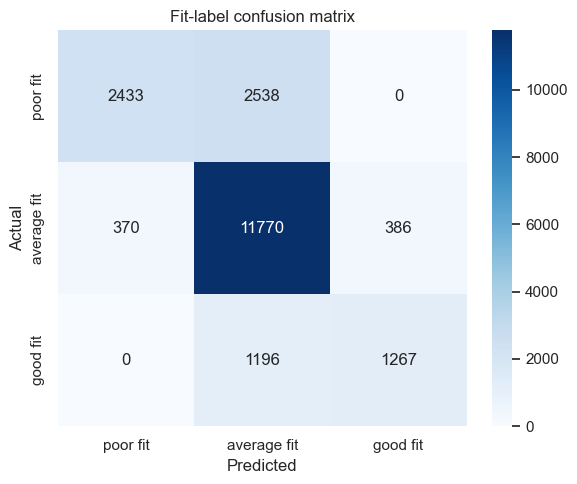

In [7]:
labels = ["poor fit", "average fit", "good fit"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Fit-label confusion matrix")
plt.tight_layout(); plt.show()

## 7. Consistency check — predictions are never absurd

In [8]:
high = test_df["score"] >= 85
bad = int(((high) & (y_pred == "poor fit")).sum())
print(f"high-match (score >= 85) predicted 'poor fit': {bad} / {int(high.sum())}")
assert bad == 0
print("PASS - no high-match pairing is ever labelled poor fit.")

high-match (score >= 85) predicted 'poor fit': 0 / 79
PASS - no high-match pairing is ever labelled poor fit.


## 8. Feature importance

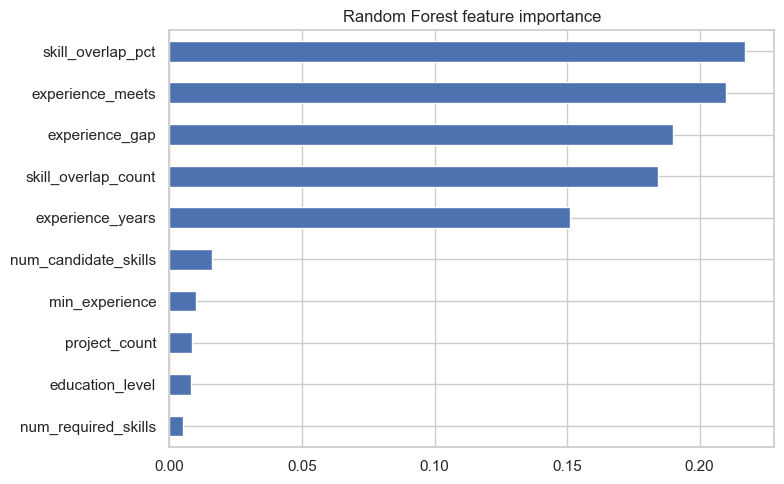

skill_overlap_pct       0.217190
experience_meets        0.210044
experience_gap          0.189819
skill_overlap_count     0.184314
experience_years        0.150987
num_candidate_skills    0.015968
min_experience          0.010048
project_count           0.008435
education_level         0.008238
num_required_skills     0.004957
dtype: float64

In [9]:
imp = pd.Series(clf.feature_importances_, index=SAFE).sort_values()
imp.plot.barh(figsize=(8, 5), title="Random Forest feature importance")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

## 9. SHAP explainability (bar + beeswarm)

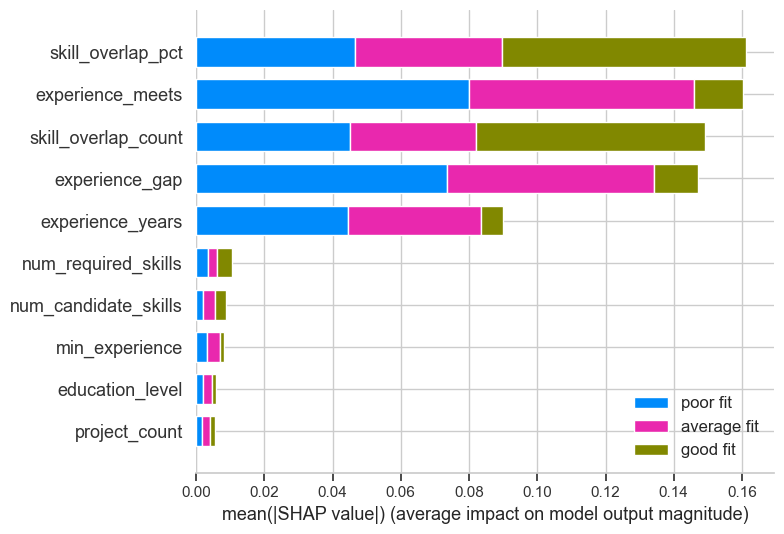

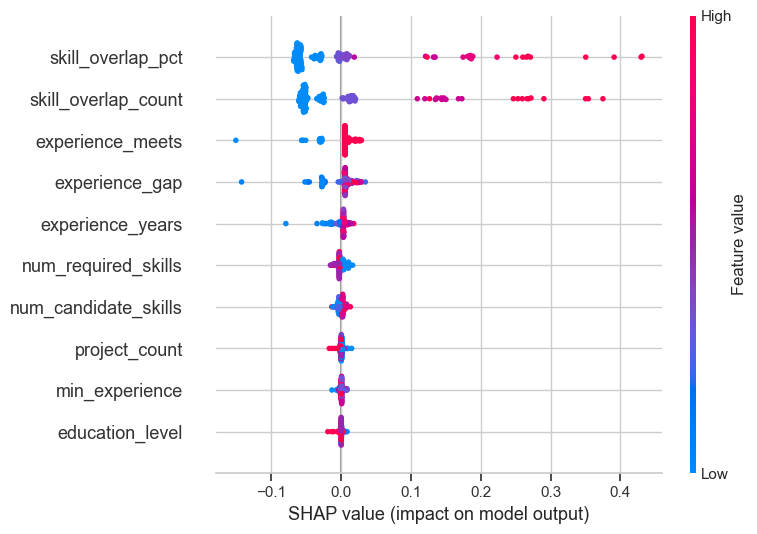

In [10]:
X_shap = X_test.iloc[:150]
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)
sv_list = (shap_values if isinstance(shap_values, list)
           else [shap_values[..., i] for i in range(shap_values.shape[-1])])
shap.summary_plot(sv_list, X_shap, plot_type="bar",
                  class_names=list(clf.classes_), show=True)
gf = list(clf.classes_).index("good fit")
shap.summary_plot(sv_list[gf], X_shap, show=True)

## 10. Error analysis

In [11]:
mis = pd.DataFrame({"actual": y_test, "predicted": y_pred})
mis = mis[mis["actual"] != mis["predicted"]]
print(f"misclassified: {len(mis)} / {len(y_test)} ({len(mis)/len(y_test):.2%})")
print("errors are mostly adjacent bands (boundary cases):")
display(mis.groupby(["actual", "predicted"]).size().rename("count").reset_index())

misclassified: 4490 / 19960 (22.49%)
errors are mostly adjacent bands (boundary cases):


,actual,predicted,count
0,average fit,good fit,386
1,average fit,poor fit,370
2,good fit,average fit,1196
3,poor fit,average fit,2538


## Summary
- **Accuracy ≈ 0.76** on the consistent fit label — a *genuine* leakage-free model (the fake 100% `role` lookup was dropped).
- **0** high-match pairings are ever called poor fit.
- Errors concentrate on adjacent bands (boundary cases), never good↔poor flips.

## 11. Save model (joblib → models/)

In [12]:
import joblib
os.makedirs(os.path.join(_ROOT, "models"), exist_ok=True)
path = os.path.join(_ROOT, "models", "jobs_fit_classifier.pkl")
joblib.dump(clf, path)
print("saved ->", path)

saved -> C:\Users\Gungun\Desktop\reetu\HireAi-ML\models\jobs_fit_classifier.pkl
